In [242]:
import torch
import torch.nn as nn
import torch.functional as f
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

from gensim.models import Word2Vec
from gensim.test.utils import common_texts

import spacy
nlp = spacy.load("en_core_web_lg")

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import accuracy_score, f1_score

import nltk
nltk.download('wordnet')
nltk.download('stopwords')

from imblearn.over_sampling import SMOTE

import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import kagglehub
%matplotlib inline

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [243]:
data = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')
data = data[['airline_sentiment', 'text']]
print(data.shape, data.info())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   airline_sentiment  14640 non-null  object
 1   text               14640 non-null  object
dtypes: object(2)
memory usage: 228.9+ KB
(14640, 2) None


,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


<BarContainer object of 3 artists>

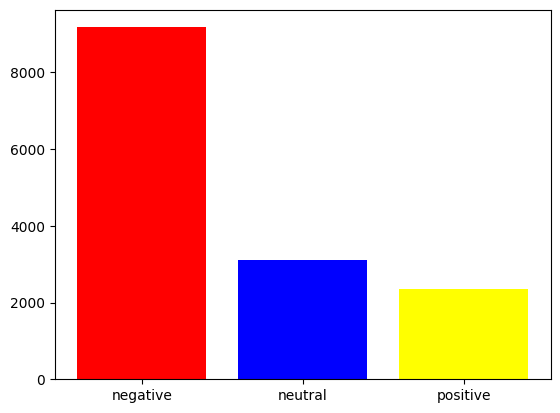

In [244]:
target_cnt = data['airline_sentiment'].value_counts()
plt.bar(target_cnt.index, target_cnt, color = ['red', 'blue', 'yellow'])

In [267]:
def prepro(text):
    _text = text.lower()
    _text = re.sub(r'@\w+', '@user', _text)
    _text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', _text)
    doc = nlp(_text)
    for ent in doc.ents:
        if ent.label_ == 'ORG':
            _text = _text.replace(ent.text, 'airline')

    _text = re.sub(r'[^a-z\s]', ' ', _text)
    return _text #, doc.ents 

def conv(x):
    if x == 'positive':
        return 2
    elif x == 'neutral':
        return 1
    elif x == 'negative':
        return 0

In [268]:
prepro('hey@AmericanAir Please bring american airlines to #BlackBerry10')

'hey user please bring airline to  blackberry  '

In [269]:
data['text'].isna().any(), data['airline_sentiment'].isna().any()

(False, False)

In [ ]:
x = data['text'].apply(prepro).to_list()
y = data['airline_sentiment'].apply(conv).to_list()

In [271]:
x_train, x_test, y_train, y_test = tts(x, y, test_size = .2, random_state = 42, stratify = y)

In [272]:
def load_glove_embeddings(filepath, embedding_dim=100):
    embeddings = {}
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            embeddings[word] = vector
    return embeddings

glove_path = '/kaggle/input/glove6b100dtxt/glove.6B.100d.txt'
glove_embeddings = load_glove_embeddings(glove_path)

In [273]:
class SentimentDataset(Dataset):
    def __init__(self, texts, sentiments, embed_model):
        self.texts = torch.tensor([self.text_to_embed(text, embed_model) for text in texts], dtype = torch.float32)
        self.sentiments = torch.tensor(sentiments, dtype = torch.int64)

    def text_to_embed(self, text, embed_model):
        words = text.split()
        embeds = [embed_model.get(word, np.zeros(100)) for word in words]
        return np.mean(embeds, axis=0)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.sentiments[idx]

In [274]:
class Model(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(hidden_dim, out_dim)
        self.log_softmax = nn.LogSoftmax(dim=1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        return self.log_softmax(x)

    def backward(self, outputs, labels, optimizer):
        loss = -torch.mean(torch.sum(labels * outputs, dim = 1))
        optimizer.zero_grad() # reset grad
        loss.backward() # do backprop
        optimizer.step() # update the weight
        return loss.item()

In [275]:
train_dataset = SentimentDataset(x_train, y_train, glove_embeddings)
test_dataset = SentimentDataset(x_test, y_test, glove_embeddings)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [276]:
in_dim = 100
hidden_dim = 256
out_dim = 3
lr = .001
epochs = 25

In [278]:
model = Model(in_dim, hidden_dim, out_dim)
weights = torch.tensor(class_weights, dtype=torch.float32)
criterion = nn.CrossEntropyLoss(weight=weights) 
optimizer = Adam(model.parameters(), lr = lr, weight_decay = 1e-5)
scheduler = StepLR(optimizer, step_size = 5, gamma = .5)
loss_h = []
loss_epochs_h = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for inputs, labels in train_loader:
        # use F(torch.nn.functional) and not f(torch.functional)
        one_hot_labels = F.one_hot(labels, num_classes=out_dim).float()
        outputs = model(inputs)
        loss = model.backward(outputs, one_hot_labels, optimizer)

        total_loss += loss
        loss_epochs_h.append(loss)
    loss_h.append(total_loss)
    scheduler.step()
    print(f'[Epoch {epoch+1}/{epochs}], Loss: {float(total_loss):.2f}')

[Epoch 1/25], Loss: 101.23
[Epoch 2/25], Loss: 81.53
[Epoch 3/25], Loss: 77.35
[Epoch 4/25], Loss: 75.05
[Epoch 5/25], Loss: 74.39
[Epoch 6/25], Loss: 70.37
[Epoch 7/25], Loss: 67.63
[Epoch 8/25], Loss: 66.01
[Epoch 9/25], Loss: 66.10
[Epoch 10/25], Loss: 64.36
[Epoch 11/25], Loss: 62.20
[Epoch 12/25], Loss: 60.84
[Epoch 13/25], Loss: 58.91
[Epoch 14/25], Loss: 59.33
[Epoch 15/25], Loss: 57.47
[Epoch 16/25], Loss: 55.64
[Epoch 17/25], Loss: 55.34
[Epoch 18/25], Loss: 54.36
[Epoch 19/25], Loss: 55.58
[Epoch 20/25], Loss: 54.96
[Epoch 21/25], Loss: 54.30
[Epoch 22/25], Loss: 53.93
[Epoch 23/25], Loss: 52.33
[Epoch 24/25], Loss: 53.90
[Epoch 25/25], Loss: 51.56


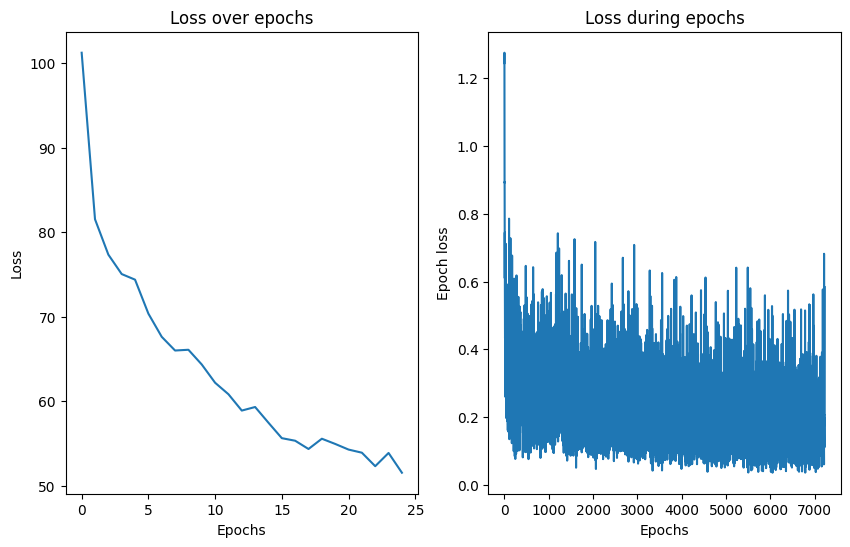

In [279]:
plt.figure(figsize = (10, 6))
plt.subplot(1, 2, 1)
plt.plot(loss_h)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over epochs')

plt.subplot(1, 2, 2)
plt.plot(loss_epochs_h)
plt.xlabel('Epochs')
plt.ylabel('Epoch loss')
plt.title('Loss during epochs')
plt.show()

In [281]:
model.eval()
all_preds = []
all_labels = []

# no grad computation when predicting
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"F1 Score: {f1:.4f}")

Accuracy: 89.65%
F1 Score: 0.8959
